# ST1504 CA2 Part B: Final Model Comparison and Demonstration

This final notebook consolidates the results from the two individual Part B notebooks:

- Kayden: C51 Distributional DQN
- Jun Hao: Lite-Rainbow DQN

The purpose is to compare both final architectures fairly, select one final group model, identify its most suitable gravity environment and demonstrate the selected trained agent through a recorded Pendulum episode.


## 1. Final C51 and Lite-Rainbow Comparison

Both models were evaluated under the same four Pendulum gravity conditions:

- Anti-gravity, $g=-10$
- Free-fall, $g=0$
- Default gravity, $g=10$
- Supergravity, $g=15$

The final comparison uses the same 30 unseen seeds, 2000–2029. Exploration and learning were disabled during evaluation. Because Pendulum returns are negative, a return closer to zero indicates better control.


### Final C51 DQN results

Kayden's model improves the standard DQN using C51 distributional learning. Instead of predicting only one expected Q-value, C51 predicts a probability distribution across 51 possible returns for each action.


### Final Lite-Rainbow DQN results

Jun Hao's Lite-Rainbow model combines three improvements:

- Double DQN to reduce action-value overestimation
- Dueling Network streams to estimate state value and action advantage separately
- Prioritised Experience Replay to revisit more informative transitions


### Recorded comparison results

The following results were recorded from the final held-out evaluation sections of the two individual Part B notebooks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gravity_order = ["Anti-gravity", "Free-fall", "Default", "Supergravity"]

comparison_results = pd.DataFrame({
    "Gravity": gravity_order,
    "Gravity Value": [-10, 0, 10, 15],
    "Final C51 Mean": [-62.30, -48.65, -183.08, -230.72],
    "Final C51 Std": [52.16, 41.67, 135.15, 157.06],
    "Lite-Rainbow Mean": [-50.75, -45.22, -169.86, -189.03],
    "Lite-Rainbow Std": [46.98, 38.83, 98.34, 119.04]
})

comparison_results["Lite-Rainbow Gain"] = (
    comparison_results["Lite-Rainbow Mean"]
    - comparison_results["Final C51 Mean"]
)

comparison_results["Winner"] = np.where(
    comparison_results["Lite-Rainbow Mean"]
    > comparison_results["Final C51 Mean"],
    "Lite-Rainbow",
    "C51"
)

display(comparison_results.round(2))


,Gravity,Gravity Value,Final C51 Mean,Final C51 Std,Lite-Rainbow Mean,Lite-Rainbow Std,Lite-Rainbow Gain,Winner
0,Anti-gravity,-10,-62.30,52.16,-50.75,46.98,11.55,Lite-Rainbow
1,Free-fall,0,-48.65,41.67,-45.22,38.83,3.43,Lite-Rainbow
2,Default,10,-183.08,135.15,-169.86,98.34,13.22,Lite-Rainbow
3,Supergravity,15,-230.72,157.06,-189.03,119.04,41.69,Lite-Rainbow


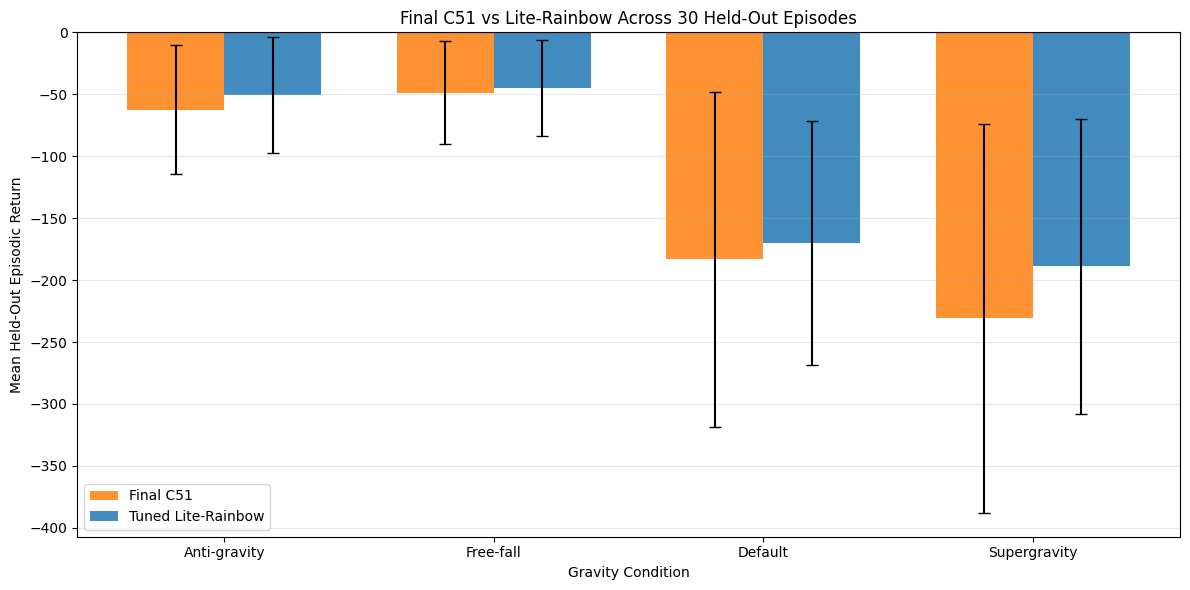

In [2]:
x = np.arange(len(comparison_results))
width = 0.36

plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    comparison_results["Final C51 Mean"],
    width,
    yerr=comparison_results["Final C51 Std"],
    capsize=4,
    color="tab:orange",
    alpha=0.85,
    label="Final C51"
)
plt.bar(
    x + width / 2,
    comparison_results["Lite-Rainbow Mean"],
    width,
    yerr=comparison_results["Lite-Rainbow Std"],
    capsize=4,
    color="tab:blue",
    alpha=0.85,
    label="Tuned Lite-Rainbow"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, comparison_results["Gravity"])
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Held-Out Episodic Return")
plt.title("Final C51 vs Lite-Rainbow Across 30 Held-Out Episodes")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Model selection

| Gravity | Final C51 Mean | Lite-Rainbow Mean | Lite-Rainbow Gain | Winner |
|---|---:|---:|---:|---|
| Anti-gravity | -62.30 | **-50.75** | +11.55 | Lite-Rainbow |
| Free-fall | -48.65 | **-45.22** | +3.43 | Lite-Rainbow |
| Default | -183.08 | **-169.86** | +13.22 | Lite-Rainbow |
| Supergravity | -230.72 | **-189.03** | +41.69 | Lite-Rainbow |

Lite-Rainbow achieves the higher mean return in all four gravity conditions. Its average mean return across the four environments is **-113.72**, compared with **-131.19** for C51. Therefore, **Lite-Rainbow DQN is selected as the final group architecture**.

This decision is based on held-out episodic return rather than training loss. The two architectures use different learning objectives, so their loss values cannot be compared directly.


## 2. Selection of the Final Gravity Environment

After selecting Lite-Rainbow as the final architecture, its performance is compared across the four environments. The most suitable environment is the one with the highest mean return. Standard deviation is also considered because a smaller value indicates more consistent performance across unseen initial states.


In [3]:
rainbow_environment_results = comparison_results[[
    "Gravity",
    "Gravity Value",
    "Lite-Rainbow Mean",
    "Lite-Rainbow Std"
]].copy()

best_environment_index = rainbow_environment_results[
    "Lite-Rainbow Mean"
].idxmax()

best_environment = rainbow_environment_results.loc[best_environment_index]

display(rainbow_environment_results.round(2))
print("Selected model: Tuned Lite-Rainbow DQN")
print(
    "Selected environment:",
    f"{best_environment['Gravity']} (g={int(best_environment['Gravity Value'])})"
)
print(f"Mean held-out return: {best_environment['Lite-Rainbow Mean']:.2f}")
print(f"Held-out standard deviation: {best_environment['Lite-Rainbow Std']:.2f}")


,Gravity,Gravity Value,Lite-Rainbow Mean,Lite-Rainbow Std
0,Anti-gravity,-10,-50.75,46.98
1,Free-fall,0,-45.22,38.83
2,Default,10,-169.86,98.34
3,Supergravity,15,-189.03,119.04


Selected model: Tuned Lite-Rainbow DQN
Selected environment: Free-fall (g=0)
Mean held-out return: -45.22
Held-out standard deviation: 38.83


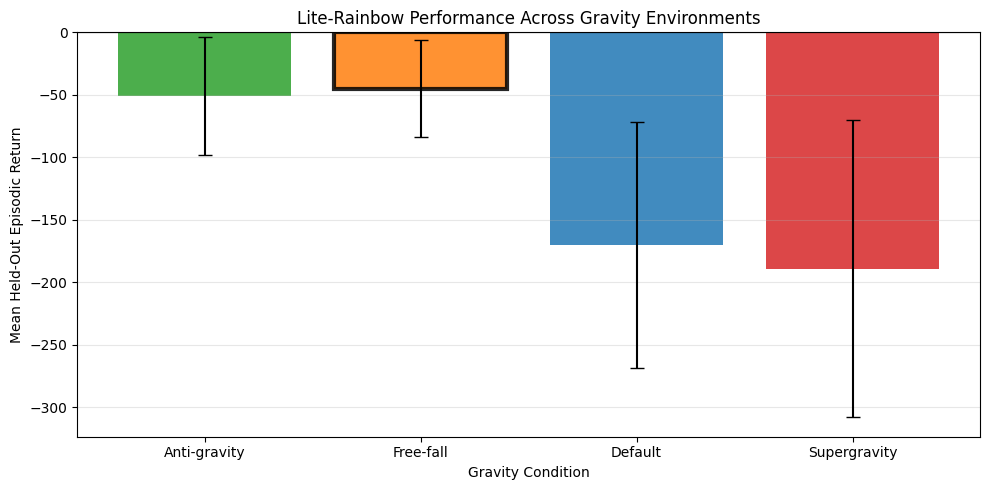

In [4]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    rainbow_environment_results["Gravity"],
    rainbow_environment_results["Lite-Rainbow Mean"],
    yerr=rainbow_environment_results["Lite-Rainbow Std"],
    capsize=5,
    color=["tab:green", "tab:orange", "tab:blue", "tab:red"],
    alpha=0.85
)

bars[best_environment_index].set_edgecolor("black")
bars[best_environment_index].set_linewidth(3)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Held-Out Episodic Return")
plt.title("Lite-Rainbow Performance Across Gravity Environments")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Environment selection

**Free-fall, $g=0$, is selected as the final demonstration environment.**

It produces the best Lite-Rainbow mean return of **-45.22**, which is closest to zero. It also has the lowest standard deviation of **38.83**, indicating the most consistent performance among the four gravity conditions.

This does not mean Free-fall is the only environment the architecture can control. A separate Lite-Rainbow agent was trained for each gravity because the transition dynamics differ between environments. Free-fall is selected only as the clearest final demonstration of the chosen architecture.


## 3. Restore the Final Lite-Rainbow Agent

The final demonstration uses Jun Hao's saved Free-fall Lite-Rainbow weights:

`junhao_tuned_rainbowdqn_g0.weights.h5`

The network structure below matches the trained Lite-Rainbow model. Only inference functions are required because the final notebook does not continue training.


In [5]:
from pathlib import Path
import gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

FINAL_CONFIG = {
    "gravity": 0.0,
    "hidden_size": 128,
    "num_actions": 21,
    "action_range": (-2.0, 2.0)
}

FINAL_WEIGHTS_PATH = Path(
    "junhao_tuned_rainbowdqn_g0.weights.h5"
)

print("Final weights:", FINAL_WEIGHTS_PATH.resolve())
print("Weights found:", FINAL_WEIGHTS_PATH.exists())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Final weights: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\junhao_tuned_rainbowdqn_g0.weights.h5
Weights found: False


In [6]:
FINAL_WEIGHTS_PATH = Path(
    r"jhptBweights\junhao_tuned_rainbowdqn_g0.weights.h5"
)

print("Final weights:", FINAL_WEIGHTS_PATH)
print("Weights found:", FINAL_WEIGHTS_PATH.exists())

class FinalLiteRainbowAgent:
    def __init__(self, state_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(config["num_actions"])
        self.action_space = np.linspace(
            config["action_range"][0],
            config["action_range"][1],
            self.action_dim
        )
        self.hidden_size = int(config["hidden_size"])
        self.model = self._build_dueling_model()

    def _build_dueling_model(self):
        inputs = layers.Input(shape=(self.state_dim,))
        x = layers.Dense(self.hidden_size, activation="relu")(inputs)
        x = layers.Dense(self.hidden_size, activation="relu")(x)

        state_value = layers.Dense(64, activation="relu")(x)
        state_value = layers.Dense(1)(state_value)

        advantage = layers.Dense(64, activation="relu")(x)
        advantage = layers.Dense(self.action_dim)(advantage)

        outputs = layers.Lambda(
            lambda values: values[0] + (
                values[1]
                - tf.reduce_mean(values[1], axis=1, keepdims=True)
            )
        )([state_value, advantage])

        return Model(inputs=inputs, outputs=outputs)

    def act(self, state):
        state_tensor = tf.convert_to_tensor(
            np.asarray(state, dtype=np.float32)[None, :]
        )
        q_values = self.model(state_tensor, training=False).numpy()[0]
        return int(np.argmax(q_values))

    def index_to_action(self, action_index):
        return np.array(
            [self.action_space[action_index]],
            dtype=np.float32
        )


final_agent = FinalLiteRainbowAgent(
    state_dim=3,
    config=FINAL_CONFIG
)

if not FINAL_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        "Place junhao_tuned_rainbowdqn_g0.weights.h5 "
        "in the same folder as this notebook."
    )

final_agent.model.load_weights(str(FINAL_WEIGHTS_PATH))
print("Final Free-fall Lite-Rainbow weights loaded successfully.")


Final weights: jhptBweights\junhao_tuned_rainbowdqn_g0.weights.h5
Weights found: True
Final Free-fall Lite-Rainbow weights loaded successfully.


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)


## 4. Final Pendulum Video Demonstration

One unseen initial state is used to demonstrate the final greedy policy. The environment records the standard red Pendulum animation as an MP4 file. No exploration or model updates occur during this episode.


In [7]:
from IPython.display import Video, display

VIDEO_DIRECTORY = Path("final_part_b_video")
VIDEO_DIRECTORY.mkdir(parents=True, exist_ok=True)

video_env = gym.make("Pendulum-v1", render_mode="rgb_array")
video_env.unwrapped.g = FINAL_CONFIG["gravity"]
video_env = gym.wrappers.RecordVideo(
    video_env,
    video_folder=str(VIDEO_DIRECTORY),
    name_prefix="final_lite_rainbow_free_fall",
    episode_trigger=lambda episode_id: episode_id == 0
)

reset_result = video_env.reset(seed=2000)
state = reset_result[0] if isinstance(reset_result, tuple) else reset_result
done = False
total_return = 0.0

while not done:
    action_index = final_agent.act(state)
    action = final_agent.index_to_action(action_index)
    step_result = video_env.step(action)

    if len(step_result) == 5:
        state, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
    else:
        state, reward, done, _ = step_result

    total_return += float(reward)

video_env.close()

video_paths = sorted(
    VIDEO_DIRECTORY.glob("*.mp4"),
    key=lambda path: path.stat().st_mtime
)

if not video_paths:
    raise FileNotFoundError(
        "No video was produced. Install MoviePy and rerun this cell."
    )

final_video_path = video_paths[-1]
print(f"Demonstration return: {total_return:.2f}")
print(f"Video saved to: {final_video_path.resolve()}")
display(Video(str(final_video_path), embed=True, width=600))


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\record_video.py:78: UserWarning: WARN: Overwriting existing videos at c:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\final_part_b_video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Demonstration return: -2.98
Video saved to: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\final_part_b_video\final_lite_rainbow_free_fall-episode-0.mp4


### Video interpretation

The animation provides a qualitative demonstration of the selected policy. The agent observes the pendulum's angle and angular velocity, selects one of 21 discrete torque values and attempts to rotate and stabilise the red pendulum near the upright position.

The demonstration is supplementary evidence. The final model decision remains based on the 30 held-out evaluation episodes rather than a single visually successful episode.


## 5. Final Conclusion

This project compared two improved DQN approaches for controlling the Pendulum environment: **C51 Distributional DQN** and **Lite-Rainbow DQN**. Both were tested under Anti-gravity, Free-fall, Default gravity and Supergravity using the same 30 unseen evaluation seeds.

Lite-Rainbow achieved a higher mean return than C51 in all four environments. It improved upon C51 by **11.55 points under Anti-gravity**, **3.43 points under Free-fall**, **13.22 points under Default gravity** and **41.69 points under Supergravity**. Its overall average mean return was **-113.72**, compared with **-131.19** for C51.

Therefore, **tuned Lite-Rainbow DQN is selected as the final group model**. Its combination of Double DQN, Dueling Network streams and Prioritised Experience Replay produced stronger and more consistent held-out performance than the final C51 agents.

Among the four environments, **Free-fall was the most suitable environment for Lite-Rainbow**, achieving the best mean return of **-45.22** and the lowest standard deviation of **38.83**. The trained Free-fall Lite-Rainbow agent was therefore used for the final video demonstration.

The results also show that gravity changes the difficulty of the control task. Performance decreased under Default gravity and Supergravity because the agent had to overcome stronger gravitational forces. Nevertheless, Lite-Rainbow's largest advantage over C51 occurred under Supergravity, demonstrating better performance under the most demanding condition.

One limitation is that each architecture was trained once per gravity. Future work could repeat training with multiple training seeds, increase the training budget and evaluate additional hyperparameter combinations. This would determine whether Lite-Rainbow's advantage remains consistent across independent training runs.


## References

1. Bellemare, M. G., Dabney, W., & Munos, R. (2017). *A Distributional Perspective on Reinforcement Learning*. https://arxiv.org/abs/1707.06887
2. van Hasselt, H., Guez, A., & Silver, D. (2015). *Deep Reinforcement Learning with Double Q-learning*. https://arxiv.org/abs/1509.06461
3. Wang, Z. et al. (2015). *Dueling Network Architectures for Deep Reinforcement Learning*. https://arxiv.org/abs/1511.06581
4. Schaul, T. et al. (2015). *Prioritized Experience Replay*. https://arxiv.org/abs/1511.05952
5. OpenAI Gym. *Pendulum Environment*. https://www.gymlibrary.dev/environments/classic_control/pendulum/
